# Projet complexité 2026

- Abdelrahim YAKHLEF
- Prénom NOM

Détection de communautés dans les graphes.

## Usage de l'intelligence artificielle

Conformément aux consignes, nous signalons ci-dessous tous les endroits du projet
où une IA générative a été utilisée.

| Section | Outil | Nature de l'assistance |
|---|---|---|
| 1.2 Rappels de complexité | IA GEMINI MODEL PRO A 120€| Aucune |
| 2.1 Générateur de graphes | — | Aucune |
| 2.2 Girvan-Newman | — | À compléter |
| 2.3 Louvain | — | À compléter |
| 2.4 Propagation d'étiquettes | — | À compléter |
| 4 Comparaisons | — | À compléter |

Tout code issu d'une IA a été relu, testé et commenté par le binôme.

## 1. Introduction

### 1.1 Objet du projet

Ce projet porte sur la détection de communautés dans les graphes. Étant donné un
graphe, on cherche à partitionner ses sommets en groupes denses en interne et
faiblement connectés entre eux. La qualité d'une partition est le plus souvent
mesurée par la modularité, dont la maximisation exacte est un problème
NP-difficile. Les algorithmes que nous étudions sont donc des heuristiques,
dont les performances théoriques et empiriques diffèrent fortement.

L'objectif est de comparer ces heuristiques sur des graphes synthétiques et
réels, en reliant leurs comportements observés à leur complexité théorique



<img src="Graphe-Clustering.png" width="500"/>

*Figure 1. Exemple de partition d'un graphe en communautés. Les sommets d'une
même communauté sont denses en interne et peu connectés au reste du graphe.*

### 1.2 Remarque sur l'usage des bibliothèques

Les algorithmes de détection de communautés sont disponibles dans des
bibliothèques telles que NetworkX. Vous pouvez les utiliser directement ou en
écrire votre propre version : ce choix n'entre pas dans l'évaluation. En
revanche, pour chaque algorithme étudié, vous devez être capables d'expliquer
son principe et de montrer que vous l'avez compris, en illustrant à la main
une itération complète sur une petite instance, avec les calculs
intermédiaires.

### 1.3.1 Rappels de complexité

La complexité d'un algorithme décrit la croissance des ressources consommées
(temps, mémoire) en fonction de la taille de l'entrée. On distingue les
problèmes polynomiaux, pour lesquels il existe un algorithme dont le temps
d'exécution est borné par un polynôme en la taille de l'entrée, et les
problèmes NP-difficiles, pour lesquels aucun algorithme polynomial connu
n'existe à ce jour. 
A lorigine la complexité est une branche des mathématiques, plus particulièrement de l'informatique théorique, qui analyse de manière formelle **le temps de calcul** et **la mémoire utilisée** nécessaires à un algorithme pour résoudre un problème.

Elle consiste à :
- Évaluer la difficulté intrinsèque des problèmes
- Les classer selon leur complexité
- Examiner les relations entre ces différentes classes

### 1.3.2 Les notions fondamentales

#### Taille d'entrée ($n$)

Le paramètre qui influence le comportement d'un algorithme est la **taille d'entrée** notée **$n$**.

N qu'on peut trouver dans une instance de boucle "for n in range ..."
OU encore une boucle for dans une boucle for.

#### Types de complexité

**Complexité spatiale :**
Mesure la quantité de mémoire utilisée par l'algorithme en fonction de $n$.

*Exemple :
L'algorithme de Held-Karp nécessite un stockage de l'ordre de $O(n \cdot 2^n)$*

### 1.3.3 La notation $O$

#### Concept de base

La notation $O$ est une façon de décrire comment le temps d'exécution d'un algorithme augmente quand la taille des données ($n$) devient très grande.

C'est un **ordre de grandeur**, on ne s'intéresse pas au temps exact.

Exemple simple :
Si un algorithme fait $3n + 5$ opérations :
- Quand $n$ est très grand, le $+5$ devient négligeable.
- Le $3$ constant devient aussi moins important.
- La complexité est donc de **$O(n)$**.

#### 1.3.4 Les notations les plus courantes

| Notation     | Type              | Comportement                       |  Exemple                                              |
|--------------|-------------------|------------------------------------|-------------------------------------------------------|
| **$O(1)$**   | Temps constant    | Meilleure complexité possible      |Acceder a un element par son index                     |
| **$O(n)$**   | Temps linéaire    | Temps proportionnel à $n$          |Trouver le plus grand nombre dans une liste non triée. | 
| **$O(n^2)$** | Temps quadratique | Si $n$ double, temps ×4            |Le Tri à Bulles (Bubble Sort)                          |
| **$O(2^n)$** | Temps exponentiel | Si $n$ augmente de 1, temps double |Le mot de passe par force brute (binaire)              |
| **$O(n!)$**  | Temps factoriel   | Catastrophique pour $n > 20$       |Le Tri Permutation (Tri Singe déterministe)            |




#### 1.3.5 Règles simples

##### On garde le terme de plus haut degré

Dans une expression polynomiale, le terme avec l'exposant le plus élevé domine complètement le comportement asymptotique. Les termes de degré inférieur deviennent négligeables lorsque $n \to \infty$.

**Exemples :**
- $O(3n^2 + 2n + 10) \rightarrow O(n^2)$
- $O(n^3 + 100n^2 + 50n) \rightarrow O(n^3)$
- $O(2^n + n^(10)) \rightarrow O(2^n)$

##### On ignore les constantes multiplicatives

Les constantes ne changent pas la **nature de la croissance**, seulement son facteur d'échelle. La notation $O$ classe les algorithmes par **type de croissance**, pas par performance absolue.

**Exemples :**
- $O(5n) \rightarrow O(n)$
- $O(n/2) \rightarrow O(n)$
- $O(100n^2) \rightarrow O(n²)$
- $O(3n!) \rightarrow O(n!)$

##### 1.3.6 Comportement asymptotique

L'analyse de complexité vise à comprendre comment l'algorithme se comporte sur de **très grandes instances** de problème.

**Conséquences :**
- Seul le comportement quand $n \to \infty$ compte
- Les termes négligeables sont éliminés
- L'objectif est d'identifier la **tendance** de croissance


[... compléter les définitions, et exemples chiffrés par exemple en comparant deux complexités ...]



In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time
import random

from projet_A2026_utils import (
    generate_planted_partition_graph,
    load_real_graph,
    girvan_newman_communities,
    louvain_communities,
    label_propagation_communities,
    exact_modularity_maximization,
    modularity,
    plot_communities,
    benchmark_communities,
)

np.random.seed(0)
random.seed(0)

## 2. Algorithmes de détection de communautés

### 2.1 Le problème et la modularité

Soit $G = (V, E)$ un graphe non orienté, $A$ sa matrice d'adjacence, $k_i$ le
degré du sommet $i$ et $m$ le nombre d'arêtes. La modularité d'une partition
$\mathcal{C}$ est définie par

$$
Q(\mathcal{C}) = \frac{1}{2m} \sum_{i,j}
\left( A_{ij} - \frac{k_i k_j}{2m} \right) \delta(c_i, c_j)
$$

où $c_i$ désigne la communauté du sommet $i$ et $\delta$ le symbole de
Kronecker. La valeur de $Q$ est comprise entre $-1$ et $1$ ; elle est positive
lorsque la partition capture mieux que le hasard la structure du graphe.

Maximiser $Q$ sur l'ensemble des partitions est un problème NP-difficile :
Pour 3 sommets : 5 partitions.
Pour 10 sommets : 115 975 partitions.
Pour 20 sommets : plus de 51 trillions de partitions. .
Donc au dessus de environ 15 sommmets l'algorithme devient inexploitable.
Les algorithmes présentés ci-dessous sont donc des heuristiques.

### 2.2 Girvan-Newman

**Principe.** L'algorithme supprime itérativement l'arête de plus forte
betweenness, c'est-à-dire celle qui est traversée par le plus grand nombre de
plus courts chemins. Les arêtes reliant deux communautés ont une betweenness
élevée et disparaissent en premier, ce qui fait éclater progressivement les
communautés.

**Complexité.** Le calcul des betweenness coûte $O(n \cdot m)$ par itération,
et il y a $m$ itérations, soit $O(n \cdot m^2)$ dans la version naïve.
algo : 


**Illustration manuelle d'une itération.** [À compléter ]

### 2.3 Louvain

**Principe.** L'algorithme alterne deux phases. Dans la première, chaque sommet
est déplacé vers la communauté voisine qui augmente le plus la modularité, et
ce jusqu'à stabilisation. Dans la seconde, chaque communauté est contractée en
un super-sommet, et on recommence. L'algorithme s'arrête lorsqu'aucun gain de
modularité n'est possible.

**Complexité.** Quasi-linéaire en pratique, $O(m \log n)$ sur la plupart des
graphes réels.

**Illustration manuelle d'une itération.** [À compléter ]

### 2.4 Propagation d'étiquettes

**Principe.** Chaque sommet reçoit initialement une étiquette unique. À chaque
itération, chaque sommet adopte l'étiquette majoritaire chez ses voisins, les
égalités étant tranchées aléatoirement. L'algorithme converge lorsque les
étiquettes se stabilisent.

**Complexité.** Chaque itération coûte $O(m)$, et le nombre d'itérations est
en pratique petit, ce qui donne une complexité quasi-linéaire.

**Illustration manuelle d'une itération.** [À compléter]

In [15]:
# Graphe à communautés plantées
G = generate_planted_partition_graph(
    n=60, n_com=3, p_in=0.35, p_out=0.03, seed=42
)

# Détection par Girvan-Newman
com_gn = girvan_newman_communities(G, n_communities=3)
Q_gn = modularity(G, com_gn)
print(f"Girvan-Newman : Q = {Q_gn:.4f}, {len(com_gn)} communautés")

# Détection par Louvain
com_lv = louvain_communities(G)
Q_lv = modularity(G, com_lv)
print(f"Louvain       : Q = {Q_lv:.4f}, {len(com_lv)} communautés")

# Détection par propagation d'étiquettes
com_lp = label_propagation_communities(G)
Q_lp = modularity(G, com_lp)
print(f"Label Prop.   : Q = {Q_lp:.4f}, {len(com_lp)} communautés")

# Visualisation
plot_communities(G, com_gn, title="Girvan-Newman")
plot_communities(G, com_lv, title="Louvain")
plot_communities(G, com_lp, title="Propagation d'étiquettes")

NotImplementedError: 

### 2.5 Recherche exhaustive (Force brute)

**Principe.** L'algorithme génère de manière systématique absolument toutes les partitions possibles des sommets du graphe. Pour chaque partition générée, il calcule son score de modularité *Q*. À la fin de l'exploration, il conserve la partition ayant obtenu le score le plus élevé. C'est la seule méthode qui garantit mathématiquement de trouver la solution optimale, car elle explore l'intégralité de l'espace de recherche.

**Complexité.** Le nombre de partitions possibles pour un ensemble de *n* sommets correspond au nombre de Bell, noté \(B_n\). Ce nombre croît de manière pire qu'exponentielle (s'approchant de la factorielle \(O(n!)\)). Le calcul de la modularité coûtant \(O(m)\), la complexité totale est de \(O(B_n \cdot m)\). Cette méthode devient physiquement incalculable pour un ordinateur moderne dès que le graphe dépasse une quinzaine de sommets.

**Illustration manuelle d'une simple itération.** 

Exemple le plus simple : un graphe linéaire avec 3 sommets {A, B, C}.
Avec 2 arêtes entre A-B et B-C. Ainsi, A et C ne sont pas liés par une arête. 

L'algo se déroule ainsi, il génère les partitions : 

1. **Partition 1 :** {A, B, C}
2. **Partition 2 :** {A, B}, {C}
3. **Partition 3 :** {A}, {B, C}
4. **Partition 4 :** {A}, {B}, {C}
5. **Partition 5 :** {A, C}, {B} 

*Cas spécial (Partition 5) :* Il n'existe pas d'arête entre A et C. Ainsi, lors de l'application de la formule de modularité \(Q\) entre A et C :
$$Q_{AC} = 0 - \frac{1 \cdot 1}{4} = -0.25$$
Résultat de modularité négatif, l'algo va donc rejeter cette partition. Il en conclut que les partitions 3 et 4 obtiennent les meilleures modularités.
**Ci-desssous l'algo de la recherche exhustive**

Force Brute terminée ! 2 communautés trouvées.


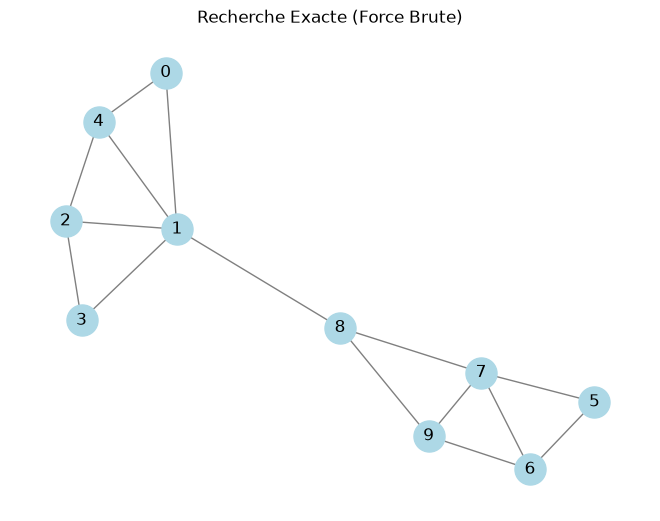

In [12]:


import networkx as nx
from networkx.algorithms.community.quality import modularity

# =====================================================================
# 1. L'USINE À COMBINAISONS (Génère toutes les partitions possibles)
# =====================================================================
def generer_toutes_les_partitions(liste_sommets):
    
    # CONDITION D'ARRÊT : S'il ne reste qu'un seul sommet à trier, 
    # il n'y a qu'une seule façon de le grouper : tout seul.
    if len(liste_sommets) == 1:
        yield [ liste_sommets ]
        return
        
    # On isole le tout premier sommet de notre liste pour s'en occuper
    premier_sommet = liste_sommets[0]
    
    # On demande à la fonction de générer les groupes pour le RESTE des sommets
    # (C'est la fameuse boucle "récursive")
    for plus_petit_groupe in generer_toutes_les_partitions(liste_sommets[1:]):
        
        # OPTION A : On insère notre 'premier_sommet' dans les groupes qui existent déjà
        for n, sous_groupe in enumerate(plus_petit_groupe):
            yield plus_petit_groupe[:n] + [[ premier_sommet ] + sous_groupe] + plus_petit_groupe[n+1:]
            
        # OPTION B : On crée un tout nouveau groupe qui ne contient QUE notre 'premier_sommet'
        yield [[ premier_sommet ]] + plus_petit_groupe


# =====================================================================
# 2. LE JURY (Évalue les combinaisons et garde la meilleure)
# =====================================================================
def maximisation_exacte_modularite(G):
    
    # On prépare des mémoires vides pour stocker notre futur record
    meilleure_partition = None
    meilleure_modularite = -1  # On commence au score le plus bas possible
    
    # On récupère la liste de tous les sommets du graphe (A, B, C, D...)
    noeuds = list(G.nodes())
    
    # On lance l'Usine (la fonction du dessus) pour tester TOUTES les combinaisons
    for partition_testee in generer_toutes_les_partitions(noeuds):
        
        # On ignore les cas absurdes qui ne font pas de vraies communautés :
        # - Tout le monde est isolé (len == len(noeuds))
        # - Tout le monde est dans le même groupe unique (len == 1)
        if len(partition_testee) == len(noeuds) or len(partition_testee) == 1:
            continue
            
        # On demande à NetworkX de calculer la note (modularité Q) de ce découpage
        score_mod = modularity(G, partition_testee)
        
        # Si ce score bat notre record actuel, on met à jour notre mémoire !
        if score_mod > meilleure_modularite:
            meilleure_modularite = score_mod
            meilleure_partition = partition_testee
            
    # Quand on a fini d'évaluer les 115 975 combinaisons (pour 10 sommets), 
    # on renvoie la grande gagnante
    return meilleure_partition


# =====================================================================
# 3. EXÉCUTION DU TEST
# =====================================================================
import matplotlib.pyplot as plt

# On crée notre petit graphe de test
G_petit = generate_planted_partition_graph(n=10, n_com=2, p_in=0.8, p_out=0.1, seed=42)

# On lance le Jury
com_exacte = maximisation_exacte_modularite(G_petit)

# On affiche le résultat et on dessine
print(f"Force Brute terminée ! {len(com_exacte)} communautés trouvées.")

nx.draw(G_petit, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
plt.title("Recherche Exacte (Force Brute)")
plt.show()

## 3. Le jeu de données Cora

Pour permettre la comparaison des résultats entre binômes, le jeu de
données Cora est imposé pour la partie comparative. Il s'agit d'un réseau
de citations extrait de publications en apprentissage automatique : chaque
sommet est un article, chaque arête une citation, et chaque article est
étiqueté par un domaine scientifique. Cette étiquette fournit la partition
de référence, qui permet de mesurer la qualité des partitions détectées
par l'information mutuelle normalisée (NMI), en complément de la
modularité.

| Caractéristique | Valeur |
|---|---|
| Sommets | 2 708 |
| Arêtes | 5 429 |
| Classes | 7 |

Source : \url{https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz}

Vous êtes libres de tester vos algorithmes sur d'autres jeux de données
réels, par exemple ceux de la collection SNAP, pourvu que Cora reste le
point de comparaison commun. Dans ce cas, précisez la source et la nature
de la partition de référence si elle existe.

In [ ]:
from projet_A2026_utils import load_cora

In [ ]:
# Exemple : graphe Cora
#G_real, ground_truth = load_real_graph("cora")
G_real, ground_truth = load_cora("cora")

print(f"Graphe : {G_real.number_of_nodes()} sommets, "
      f"{G_real.number_of_edges()} arêtes")
print(f"Communautés de référence : {len(set(ground_truth.values()))}")

# Détection avec Louvain
com_lv_real = louvain_communities(G_real)
Q_lv_real = modularity(G_real, com_lv_real)
print(f"Louvain : Q = {Q_lv_real:.4f}")

plot_communities(G_real, com_lv_real, title="Louvain sur graphe réel")

## 4. Comparaison expérimentale

### 4.1 Protocole

Nous faisons varier la taille des graphes synthétiques (de 20 à quelques
milliers de sommets) et, pour chaque taille, nous exécutons chaque algorithme
plusieurs fois en mesurant le temps d'exécution et la modularité obtenue. Pour
les graphes avec communautés de référence, nous mesurons également l'information
mutuelle normalisée (NMI) entre la partition détectée et la partition attendue.

### 4.2 Temps d'exécution

[Courbes temps en fonction de la taille, échelles linéaire et/ou logarithmique,
comparaison avec les complexités théoriques.]

### 4.3 Qualité de la partition

[Courbes modularité et NMI en fonction de la taille ou du bruit.]

### 4.4 Compromis temps / qualité

[Discussion des cas où une heuristique rapide atteint une qualité comparable à
une heuristique lente, et inversement.]

In [ ]:
sizes = [50, 100, 200, 500, 1000]
results = {}

for n in sizes:
    G = generate_planted_partition_graph(
        n=n, n_com=4, p_in=0.3, p_out=0.05, seed=n
    )
    for name, fn in [
        ("Girvan-Newman", girvan_newman_communities),
        ("Louvain", louvain_communities),
        ("Label Propagation", label_propagation_communities),
    ]:
        t, q = benchmark_communities(G, fn)
        results.setdefault(name, []).append((n, t, q))

# Tracé temps
plt.figure(figsize=(9, 6))
for name, vals in results.items():
    ns, ts, qs = zip(*vals)
    plt.plot(ns, ts, marker='o', label=name)
plt.xlabel("Nombre de sommets")
plt.ylabel("Temps d'exécution moyen (s)")
plt.xscale("log")
plt.yscale("log")
plt.title("Temps de calcul en fonction de la taille du graphe")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Tracé modularité
plt.figure(figsize=(9, 6))
for name, vals in results.items():
    ns, ts, qs = zip(*vals)
    plt.plot(ns, qs, marker='o', label=name)
plt.xlabel("Nombre de sommets")
plt.ylabel("Modularité")
plt.title("Qualité de la partition en fonction de la taille du graphe")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Conclusion

### 5.1 Synthèse

[Rappeler les écarts observés entre algorithmes, en reliant chaque observation
à la complexité théorique correspondante. Discuter des cas où la modularité
seule est un indicateur trompeur.]

### 5.2 Apports du projet

[Analyse réflexive : qu'avez-vous compris de la notion de complexité, de la
différence entre exact et approché, du rôle des heuristiques et des limites de
la modularité ?]